# 3. Customer analysis

**Business questions:** who are the most valuable customers, how many come back, and which groups are drifting away?

*Note:* RFM segment names are **analytical labels** built from project-defined thresholds (see `docs/07_customer_analytics.md`), not facts about the people.

In [1]:
import sys
sys.path.insert(0, "..")            # make the modules in python/ importable from this folder
import pandas as pd
import matplotlib.pyplot as plt
import visualization as viz
from data_extraction import get_view
pd.set_option("display.width", 160, "display.max_columns", 20, "display.float_format", "{:,.1f}".format)
%matplotlib inline

In [2]:
import customer_analysis as ca
customers = get_view('vw_customer_summary')

## Repeat customers

In [3]:
ca.repeat_rate(customers)

{'buying_customers': 7074,
 'repeat_customers': 5901,
 'repeat_customer_rate_pct': 83.41815097540288}

## Commercial segments and lifetime value (to date)

In [4]:
ca.segment_summary(customers)

,segment,customers,orders,net_revenue,avg_lifetime_revenue,avg_lifetime_profit,revenue_share_pct
0,Regular,4327,30933,"82,610,846.4","19,091.9","4,447.4",54.2
1,Premium,1049,12090,"36,826,624.8","35,106.4","8,258.9",24.1
2,Corporate,415,4040,"16,326,129.1","39,340.1","9,137.0",10.7
3,Student,1211,6774,"15,441,084.2","12,750.7","3,022.2",10.1
4,(no segment),72,423,"1,322,415.6","18,366.9","4,026.0",0.9


## RFM segments
Recency = days since last order, Frequency = number of orders, Monetary = net revenue.

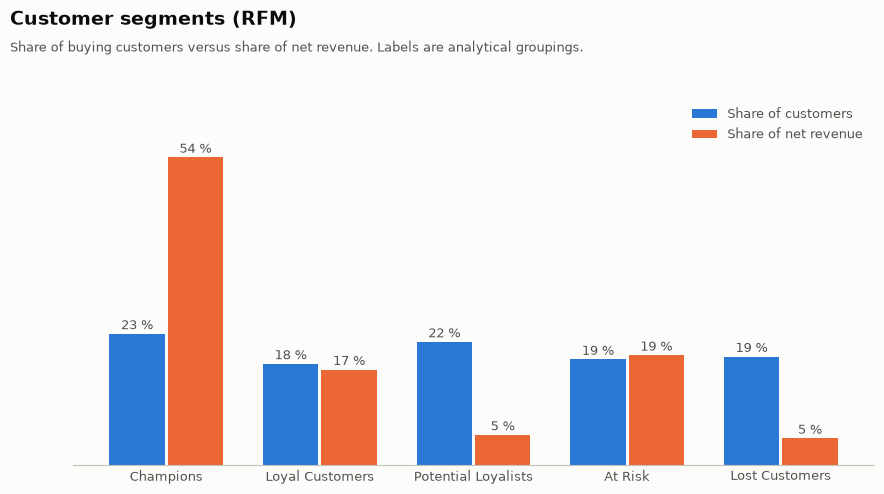

,rfm_segment,customers,net_revenue,avg_recency_days,avg_orders,customer_share_pct,revenue_share_pct
0,Champions,1630,"82,389,769.6",34.3,18.0,23.0,54.0
1,Loyal Customers,1257,"25,556,322.2",81.6,7.0,17.8,16.8
2,Potential Loyalists,1529,"8,056,193.7",67.2,1.9,21.6,5.3
3,At Risk,1311,"29,398,454.6",447.0,8.1,18.5,19.3
4,Lost Customers,1347,"7,126,359.9",527.6,1.9,19.0,4.7


In [5]:
viz.customer_segments(customers); plt.show()
ca.rfm_summary(customers)

## Activity status

In [6]:
ca.activity_status(customers)

,activity_status,customers,share_pct
0,Active (last 90 days),3376,37.0
1,Inactive (91-365 days),2126,23.3
2,Lost (over 365 days),1572,17.2
3,Never purchased,2046,22.4


## Purchase frequency and revenue concentration

In [7]:
ca.frequency_bands(customers)

,frequency_band,customers,net_revenue,customer_share_pct,revenue_share_pct
0,1 order,1173,"3,072,281.4",16.6,2.0
1,2-3 orders,1703,"12,110,272.2",24.1,7.9
2,4-6 orders,1603,"21,804,614.0",22.7,14.3
3,7-12 orders,1392,"34,918,662.1",19.7,22.9
4,13+ orders,1203,"80,621,270.2",17.0,52.9


In [8]:
ca.concentration(customers)

,decile,net_revenue,revenue_share_pct
0,10,"70,324,137.1",46.1
1,9,"29,049,374.8",19.0
2,8,"17,452,807.8",11.4
3,7,"11,902,030.3",7.8
4,6,"8,524,125.1",5.6
5,5,"6,089,720.4",4.0
6,4,"4,223,491.0",2.8
7,3,"2,763,011.4",1.8
8,2,"1,619,494.3",1.1
9,1,"578,907.8",0.4


## Cohort retention
Of the customers who first bought in a month, the percentage who buy again 1-6 months later.

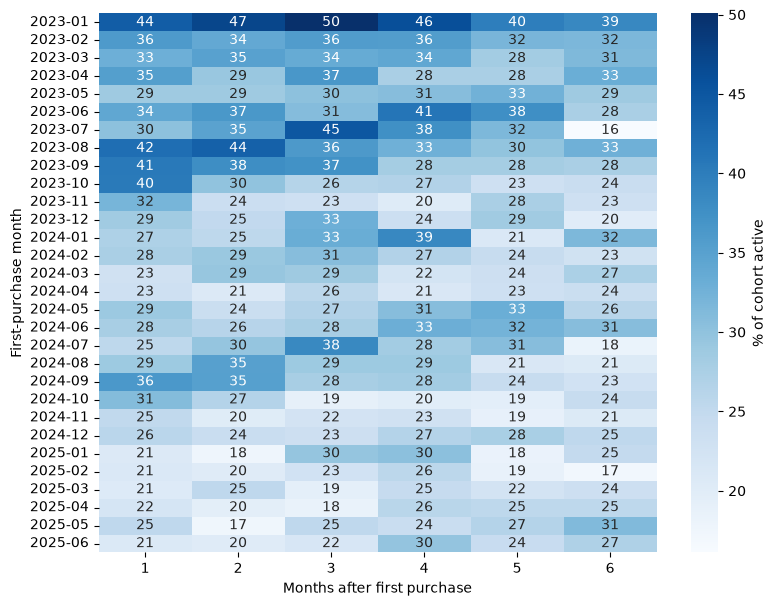

In [9]:
import seaborn as sns
ret = ca.cohort_retention()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(ret.set_index('cohort')[[1, 2, 3, 4, 5, 6]], annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': '% of cohort active'}, ax=ax)
ax.set_yticklabels([d.strftime('%Y-%m') for d in ret['cohort']], rotation=0)
ax.set_xlabel('Months after first purchase'); ax.set_ylabel('First-purchase month')
plt.show()

## Top customers

In [10]:
ca.top_customers(customers)

,customer_id,customer_name,segment,orders,net_revenue,avg_order_value,last_order_date,rfm_segment
0,3467,Bhavna Kumar,Premium,128,"433,880.3","3,886.1",2025-12-21,Champions
1,6583,Suresh Deshmukh,Corporate,77,"356,310.9","5,229.4",2025-11-29,Champions
2,7403,Kavya Patel,Premium,117,"352,955.5","3,413.1",2025-12-21,Champions
3,4104,Tarun Bansal,Corporate,70,"344,194.5","5,666.5",2025-12-27,Champions
4,3587,Kritika Patil,Corporate,24,"336,446.0","16,408.2",2025-11-02,Champions
5,6276,Aishwarya Das,Premium,110,"320,707.0","3,304.4",2025-12-23,Champions
6,2624,Mansi Ghosh,Corporate,55,"288,306.9","6,041.3",2025-12-25,Champions
7,1678,Karan Patil,Premium,66,"274,159.2","4,775.3",2025-12-28,Champions
8,5227,Pallavi Agarwal,Regular,76,"274,025.3","4,161.2",2025-12-16,Champions
9,3138,Aditya Kumar,Premium,18,"273,300.8","17,674.5",2025-09-21,Loyal Customers
